,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.000,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.000,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.000,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.000,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.000,0.043,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14091,2025,2025-11-01,"Yesavage, Trey",702056,571970,0,0,8,Top,66,...,4,2,4,Infield shade,Standard,213.0,0.000,-0.039,NaN,NaN
14092,2025,2025-11-01,"Yesavage, Trey",702056,571970,0,1,8,Top,66,...,4,2,4,Infield shade,Standard,211.0,0.000,0.028,NaN,NaN
14093,2025,2025-11-01,"Yesavage, Trey",702056,571970,1,1,8,Top,66,...,4,3,4,Infield shade,Standard,219.0,-0.099,1.593,75.2,7.4
14094,2025,2025-11-01,"Yesavage, Trey",702056,606192,0,0,8,Top,67,...,4,3,4,Standard,Standard,199.0,0.000,-0.039,75.2,8.6


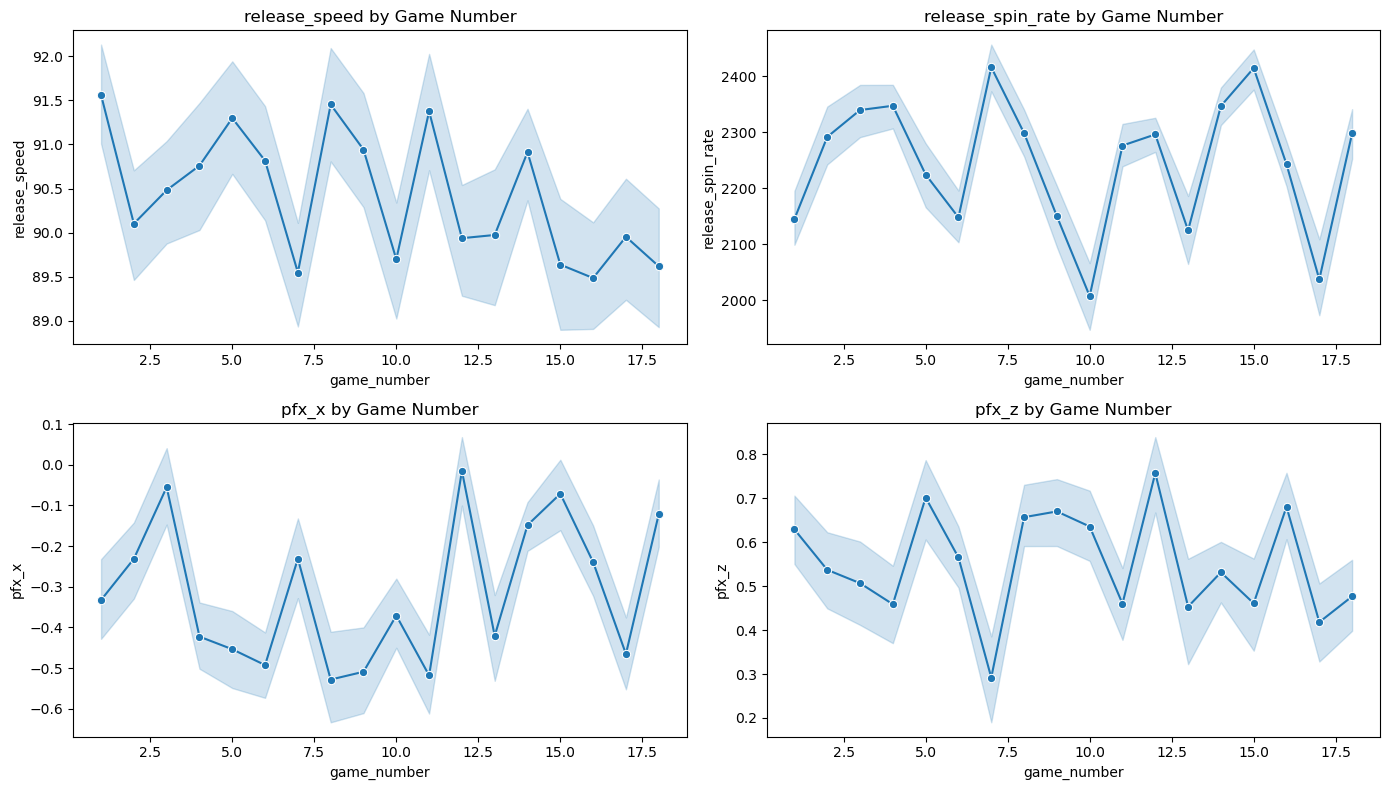

game_type
W    2384
L    1971
D    1189
Name: count, dtype: int64
             release_speed  release_spin_rate
game_number                                  
1                91.560000        2145.053571
2                90.101974        2291.555921
3                90.481290        2339.493548
4                90.759322        2347.138983
5                91.297600        2224.472000
6                90.815072        2148.014493
7                89.548921        2415.874101
8                91.451736        2298.461806
9                90.941026        2150.175824
10               89.698881        2007.600746
11               91.373978        2276.171004
12               89.937615        2296.015291
13               89.973874        2124.815315
14               90.912315        2346.688013
15               89.638148        2414.366667
16               89.486139        2242.782178
17               89.953287        2037.463668
18               89.619505        2297.925824


In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'/Users/tim/Downloads/DATA_MLB.csv')
display(df)

df_jays = df[(df['home_team'] == "TOR") | (df['away_team'] == "TOR")]

df_post = df_jays[df_jays['game_type'].isin(['F', 'D', 'L', 'W'])].copy()


df_post = df_post.sort_values('game_date')
df_game_dates = df_post['game_date'].unique()
game_num_map = {date: i+1 for i, date in enumerate(sorted(df_game_dates))}
df_post['game_number'] = df_post['game_date'].map(game_num_map)

metrics = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, metric in zip(axes.flatten(), metrics):
    sns.lineplot(data=df_post, x='game_number', y=metric, estimator='mean', ax=ax, marker='o')
    ax.set_title(f'{metric} by Game Number')
plt.tight_layout()
plt.show()

print(df_post['game_type'].value_counts())  
print(df_post.groupby('game_number')[['release_speed','release_spin_rate']].mean())

